# Basic Pipeline drawn out as a quick and dirty way for simulation model and hyper-heuristic communication.

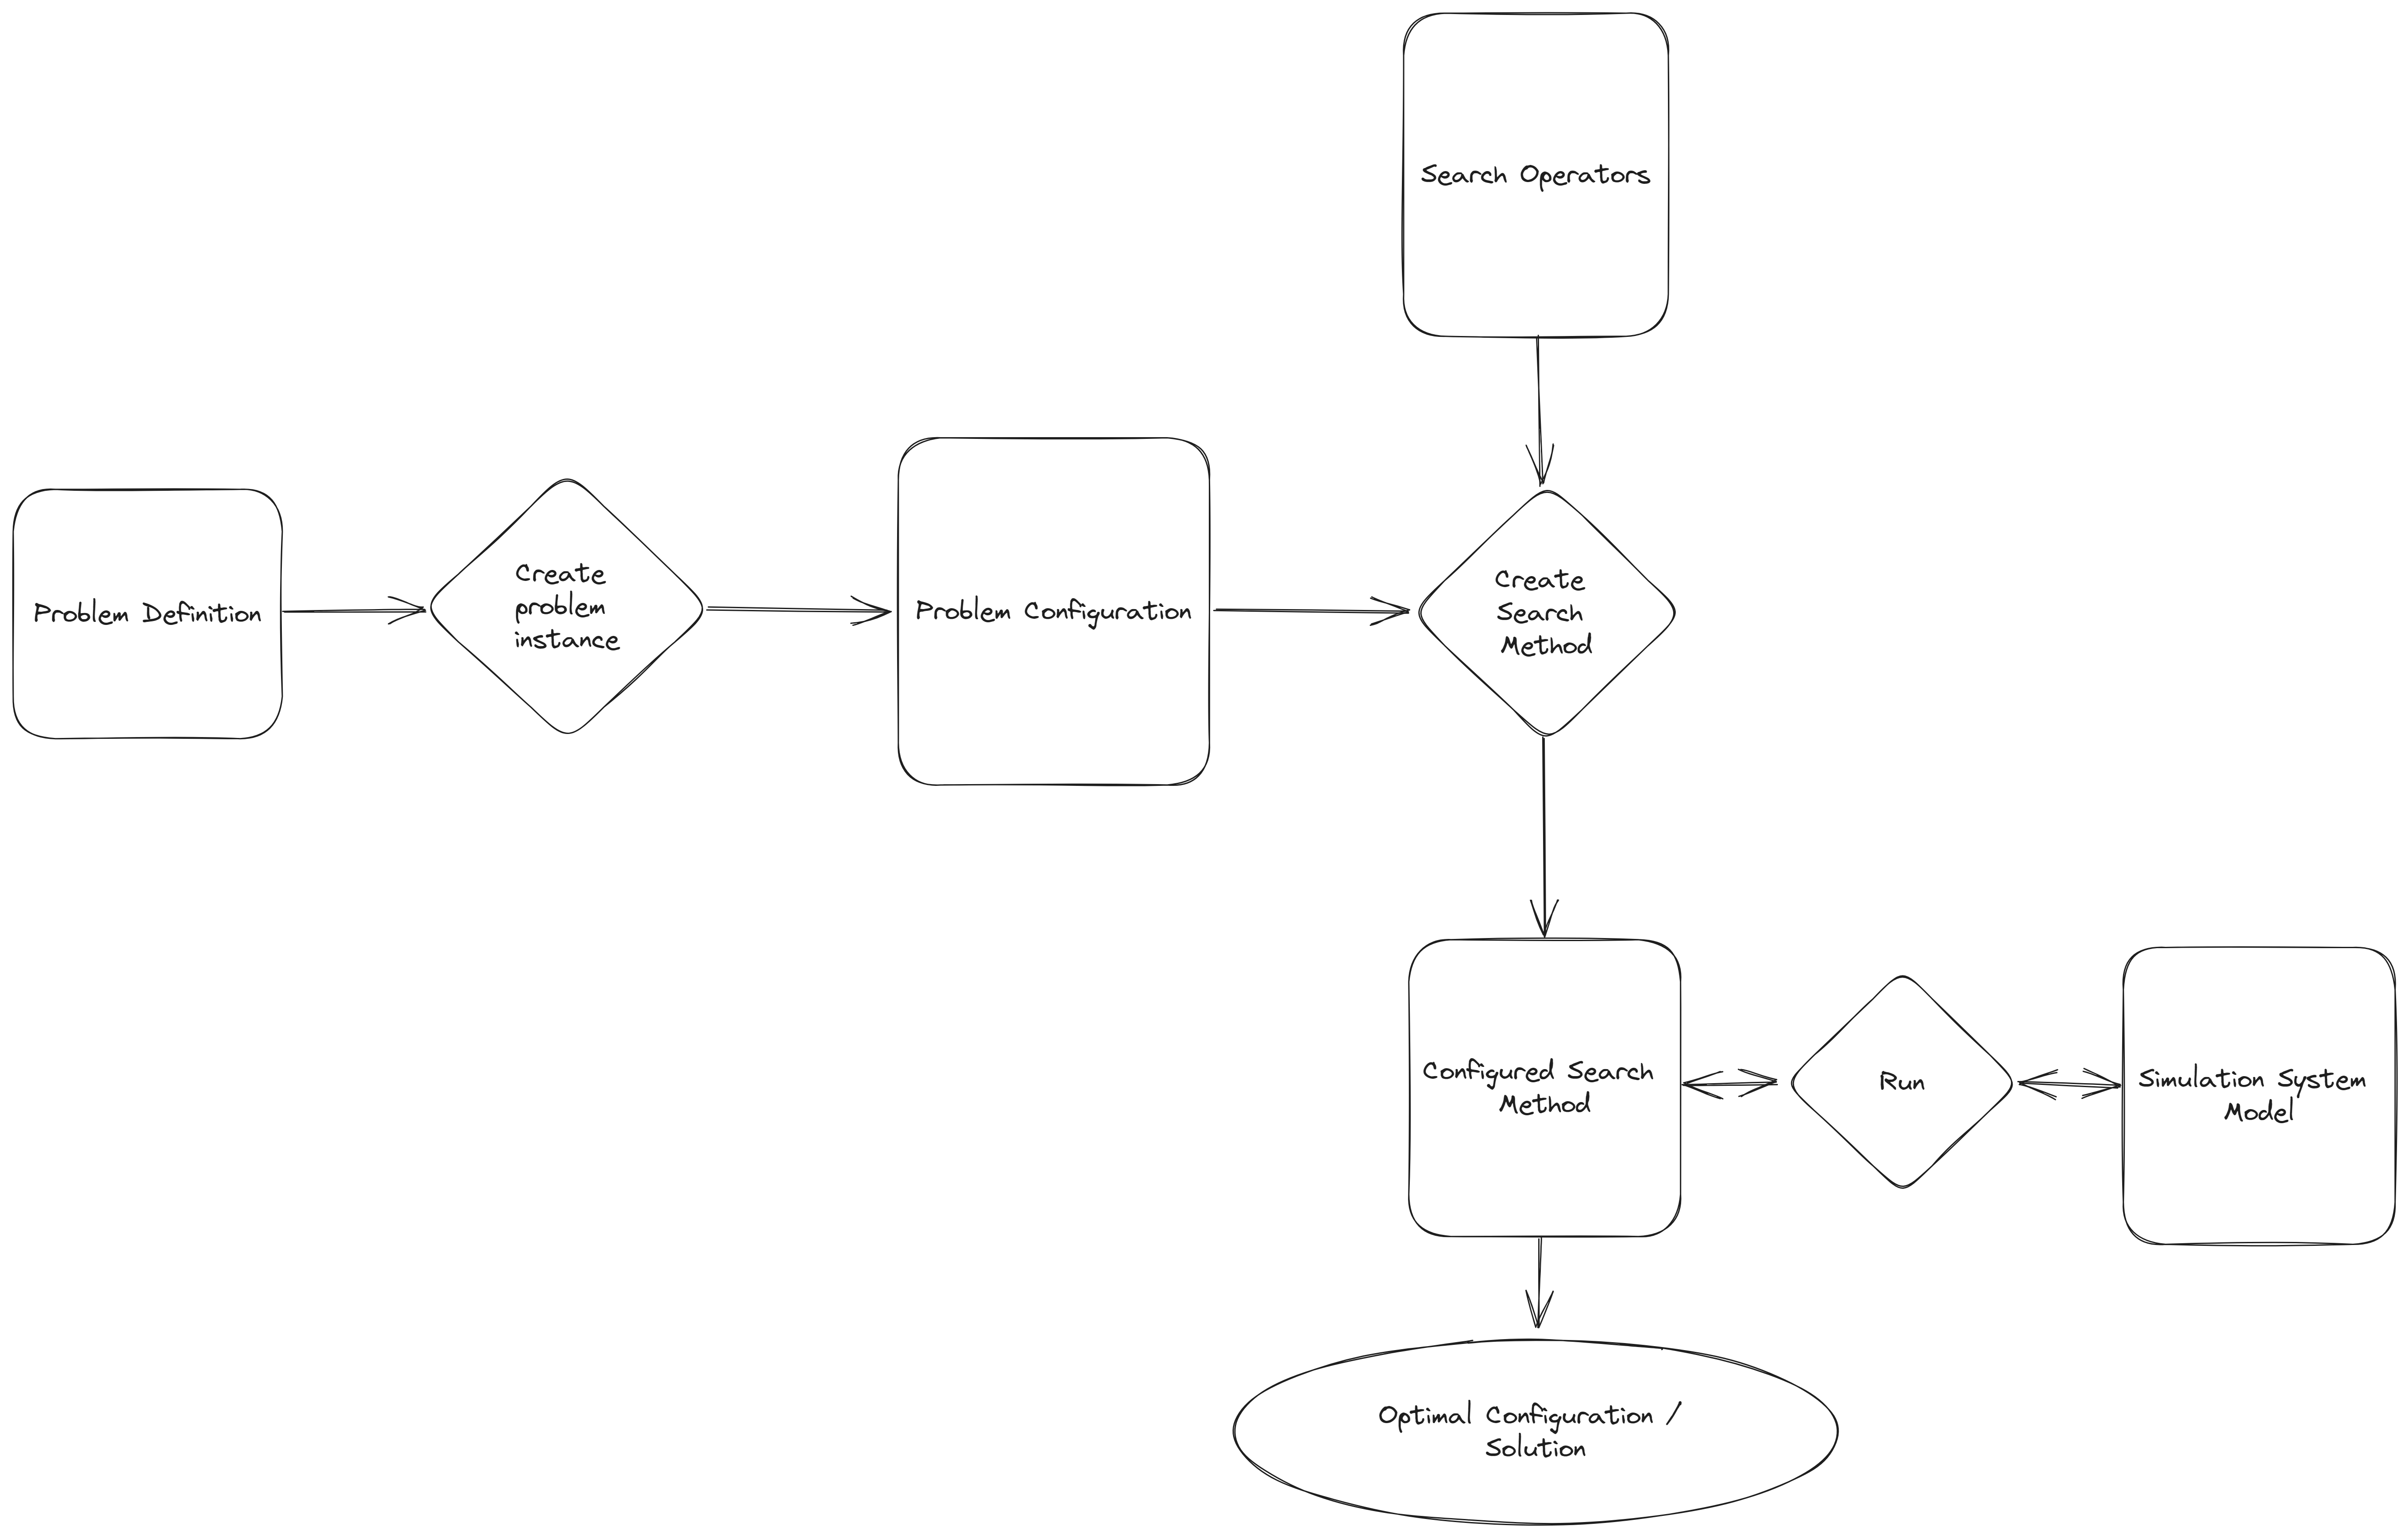

Import the packages needed for the aforementioned pipeline. The path is set to the src directory as the notebook directory is outside of the notebook directory.

In [94]:
import sys
sys.path.append('../src')

import json
import numpy as np
from external.SimulationModel.SimulationModel import SimulationModel
from external.HyperHeuristic.HyperHeuristic import HyperHeuristic

from customhys import benchmark_func as bf
from customhys import metaheuristic as mh
from customhys import hyperheuristic as hh

import matplotlib.pyplot as plt

2023-08-08 10:49:36.336806: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-08-08 10:49:36.887129: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-08-08 10:49:36.888805: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-08-08 10:49:38.898556: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Tool functions:

- Read config file
- Define the basic problem class of the CUSTOMHys framework to create custom optimisation problems.

In [78]:
def load_config(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)
    
# Import BasicProblem object for generating a custom optimisation problem.
BP = bf.BasicProblem

## Functionality: Generate problem instance for CUSTOMHys framework

#### The fitness evaluation is now a fake one; The approach would be to have this be a simulation run of some sort that returns some output about the system performance.

In [83]:
'''
    Subclass of BasicProblem object to generate a custom optimisation problem.
    
    variable_num:              Number of dimensions of the problem
    max_search_range:          Maximum boundaries of parameter values
    min_search_range:          Minimum boundaries of parameter values
    optimal_solution:          Optimal configuration of parameter values
    global_optimum_solution:   Optimal fitness value of optimal configuration
    func_name:                 Name of the function?
'''
class instance(BP):
    def __init__(self, variable_num, max_search_range, min_search_range, optimal_solution, global_optimum_solution, func_name):
        super().__init__(variable_num)
        self.max_search_range = max_search_range
        self.min_search_range = min_search_range
        self.optimal_solution = optimal_solution
        self.global_optimum_solution = global_optimum_solution
        self.func_name = func_name
        self.features = {'Continuous': False,
                            'Differentiable': False,
                            'Separable': False,
                            'Scalable': True,
                            'Unimodal': True,
                            'Convex': False}

    '''
        Fake fitness function for evaluating a closed queueing network configuration.
    '''
    def get_func_val(self, variables, *args):
        number_of_switches = variables[0]
        number_of_servers_per_queue = variables[1]
        delay_server_queue = variables[2]
        delay_queues = variables[3]

        total_servers = number_of_servers_per_queue * number_of_switches

        # Fake logic
        efficiency = total_servers / (delay_server_queue + delay_queues)
        complexity = number_of_switches

        # Combine the factors into a single fitness value
        fitness = efficiency + complexity

        return 1/fitness

def generate_instance(variable_num, instance_config):
    max_range = np.array([instance_config['boundaries'][key][1] for key in instance_config['boundaries']])
    min_range = np.array([instance_config['boundaries'][key][0] for key in instance_config['boundaries']])
    
    return instance( variable_num, 
                     max_range, 
                     min_range, 
                     instance_config['optimal_solution'], 
                     instance_config['optimal_fitness'],
                     'CQN')

In [80]:
def save_fitness(hist_values):
    inverted_values = [1 / x for x in hist_values['fitness']]
    
    plt.figure()
    plt.plot(inverted_values, lw=2)
    plt.xlabel('Iteration'), plt.ylabel('Fitness')
    plt.tight_layout()
    plt.savefig('/mnt/c/users/larry/Desktop/SE_Thesis/HH-Implementation/hh-dse-2.0/data/processed/Fake_CQN_fitness_over_iteration.png')
    plt.show()

### Run Metaheuristic

In [91]:
def run_mh(prob, heur, num_agents, num_iterations):
    
    # Generate and run a metaheuristic search method on the CQN model.
    met = mh.Metaheuristic(prob, heur, num_agents=num_agents, num_iterations=num_iterations)
    met.verbose = True
    met.run()

### Hyperheuristic

In [95]:
parameters = dict(
    cardinality=3,  # Max. numb. of SOs in MHs, lvl:1
    cardinality_min=1,  # Min. numb. of SOs in MHs, lvl:1
    num_iterations=100,  # Iterations a MH performs, lvl:1
    num_agents=30,  # Agents in population,     lvl:1
    as_mh=True,  # HH sequence as a MH?,     lvl:2
    num_replicas=30,  # Replicas per each MH,     lvl:2
    num_steps=50,  # Trials per HH step,       lvl:2
    stagnation_percentage=0.37,  # Stagnation percentage,    lvl:2
    max_temperature=100,  # Initial temperature (SA), lvl:2
    min_temperature=1e-6,  # Min temperature (SA),     lvl:2
    cooling_rate=1e-3,  # Cooling rate (SA),        lvl:2
    temperature_scheme='fast',  # Temperature updating (SA),lvl:2
    acceptance_scheme='exponential',  # Acceptance mode,          lvl:2
    allow_weight_matrix=True,  # Weight matrix,            lvl:2
    trial_overflow=False,  # Trial overflow policy,    lvl:2
    learnt_dataset=None,  # If it is a learnt dataset related with the heuristic space
    repeat_operators=True,  # Allow repeating SOs inSeq,lvl:2
    verbose=True,  # Verbose process,          lvl:2
    learning_portion=0.37,  # Percent of seqs to learn  lvl:2
    solver='static')  # Indicate which solver use lvl:1

In [ ]:
hyp = hh.Hyperheuristic(heuristic_space="default.txt",
                        problem=prob, parameters=parameters, file_label='Griewank-5D-Exp1')

best_sol, best_perf, hist_curr, hist_best = hyp.solve()

### Run the pipeline with the cqn collection in the config file.

In [92]:
def main():
    
    # Generate fake CQN problem instance from config file.
    config_path = "/mnt/c/users/larry/Desktop/SE_Thesis/HH-Implementation/hh-dse-2.0/config/config.json"
    config = load_config(config_path)
    cqn_instance = generate_instance(4, config['Simulation']['cqn'])
    prob = cqn_instance.get_formatted_problem()
    
    # Create metaheuristic search operator for random search with uniform search distribution.
    heur = [('random_search', {'scale': 1.0, 'distribution': 'uniform'}, 'greedy')]
    
    run_mh(prob, heur, 30, 100)

In [93]:
main()


Search operators to employ:
random_search(scale=1.0,distribution='uniform') with greedy
--------------------------------------------------
1
pop. radius: 1.7957826429667842
x_best = [ 8.5620166  15.          0.51438903  0.57020304], f_best = 0.007875539422232215
2
pop. radius: 1.893240251174349
x_best = [9.74078424 9.08191562 0.28992379 0.2       ], f_best = 0.005254594424441413
3
pop. radius: 1.897551083045853
x_best = [ 7.83212519 10.94847487  0.11593887  0.2       ], f_best = 0.003581086802377049
4
pop. radius: 1.9943357591372968
x_best = [10.         15.          0.10795418  0.21076746], f_best = 0.002080602098902414
5
pop. radius: 2.030677131701872
x_best = [10.         15.          0.10795418  0.21076746], f_best = 0.002080602098902414
6
pop. radius: 2.0637365802515535
x_best = [10.         15.          0.10795418  0.21076746], f_best = 0.002080602098902414
7
pop. radius: 1.964234571022018
x_best = [10.  15.   0.1  0.2], f_best = 0.001960784313725491
8
pop. radius: 1.94660266998